In [69]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F


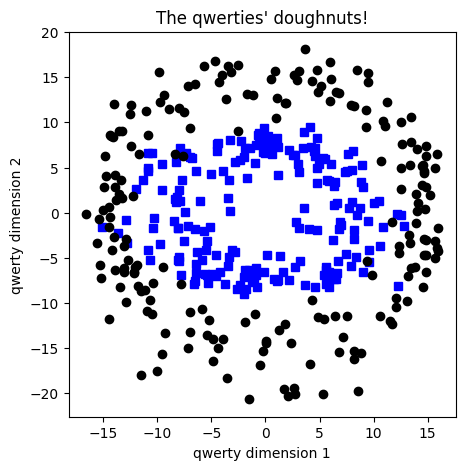

In [70]:
# create data

nPerClust = 200

th = np.linspace(0,4*np.pi,nPerClust)
r1 = 8
r2 = 15

# generate data
a = [ r1*np.cos(th) + np.random.randn(nPerClust)*3 ,
      r1*np.sin(th) + np.random.randn(nPerClust) ]
b = [ r2*np.cos(th) + np.random.randn(nPerClust) ,
      r2*np.sin(th) + np.random.randn(nPerClust)*3 ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title("The qwerties' doughnuts!")
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [71]:
#separating into training and testing set 
from sklearn.model_selection import train_test_split
X_train, X_test , y_train,y_test=train_test_split(data, labels , test_size=0.2,random_state=101)

from torch.utils.data import DataLoader , TensorDataset
train_data=TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test , y_test)

train_loader=DataLoader(train_data , batch_size=32 )
test_loader=DataLoader(test_data , batch_size=test_data.tensors[0].shape[0] )
'''
Expression	                            Meaning
test_data.tensors[0]	                X_test
.shape	                                (samples, features)
.shape[0]	                            number of samples
batch_size	                            full dataset size

so basically the test_loader we consider the whole batch

'''







'\nExpression\t                            Meaning\ntest_data.tensors[0]\t                X_test\n.shape\t                                (samples, features)\n.shape[0]\t                            number of samples\nbatch_size\t                            full dataset size\n\nso basically the test_loader we consider the whole batch\n\n'

In [72]:
#defining the model 
class ANNmodel(nn.Module):

    def __init__(self , dropoutrate):
        super().__init__()
        
        self.input=nn.Linear(2 , 128)
        self.hidden = nn.Linear(128,128)
        self.output=nn.Linear(128 , 1)
        
        self.dr=nn.Dropout(dropoutrate)
        
    def forward(self , x):
        x=self.input(x)
        
        x=F.relu(x)
        
        x=self.hidden(x)
        
        x=F.relu(x)
        
        x=self.dr(x)
        #self.tranining is boolean , it is set to true when traning and false when testing
        
        x=self.output(x)
        
        return x
        


In [73]:
def createmodel(dropoutrate):
    
    model=ANNmodel(dropoutrate)
    lr=0.001
    lossfn=nn.BCEWithLogitsLoss()
    optimizer=torch.optim.Adam(model.parameters(), lr=lr)
    epochs=1000
    return model, lossfn, optimizer
    


    
    


In [ ]:
#training the model 

def trainmodel(model ,epochs , lossfn , optimizer ):
     
     train_acc=[]
     test_acc=[]
     
     for i in range(epochs):
         
         #training model , now the dropout is on
         model.train()
         
         
        # loop over training data batches
         batchAcc = []
         for X,y in train_loader:
             
             y_pred_train=model(X)
             loss=lossfn( y_pred_train , y)
             
             #backprop
             optimizer.zero_grad()
             loss.backward()
             optimizer.step()
             
             #computing training acc for this batch
             batchAcc.append(100*torch.mean(((y_pred_train>0)==y).float()).item())
             #end of batch loop 
             
         train_acc.append(np.mean(batchAcc))
         # test accuracy
         model.eval() # switch training off
         X,y = next(iter(test_loader)) # extract X,y from test dataloader
         yHat = model(X)
         test_acc.append( 100*torch.mean(((yHat>0)==y).float()).item() )
  
    # function output
     return train_acc , test_acc

         
     
    

In [75]:
#test the model 
dropoutrate=0.5
model , lossfn , optimizer=createmodel(dropoutrate)

trainacc , testacc= trainmodel(model , 1000 , lossfn , optimizer )


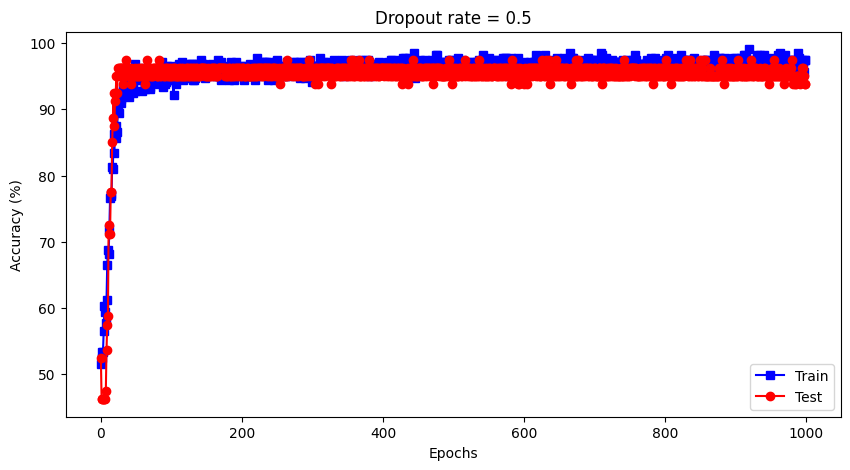

In [76]:
# plot the results
fig = plt.figure(figsize=(10,5))

plt.plot(trainacc,'bs-')
plt.plot(testacc,'ro-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(['Train','Test'])
plt.title('Dropout rate = %g'%dropoutrate)

plt.show()